# Process ATUS data

Outcomes:
- Filter and process respondent metadata and export into a csv
- Generate wide-form sequences from time diaries and export into a csv
- Perform clustering on the ATUS sequences
- Export cluster and demographic stratum codes into a csv

In [1]:
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
from helpers import atus
from helpers.plotting import cluster_tempogram_weighted_wrapper as plot_tempogram
from mobcalibrate.preprocessing import (
    compute_metrics_for_all_sequences, 
    metrics_cosine_D, 
    fit_weighted_kmedoids_with_restarts, 
    compute_dist_to_medoid_thresholds
)

%config InlineBackend.figure_format = 'retina'

### Configs (START HERE)

In [3]:
# ======================
# SAMPLE FILTERS
# ======================

CBSA_CODE = 38060

YY = 19  # get data to year 20{TY}
YEARS = list(range(2004, 2020))
#CBSA_FILTER = [CBSA_CODE]
AGE_MIN = 18


# ======================
# PATHS
# ======================
DATA_DIR = "data/atus"
OUTPUT_DIR = "data/processed"
DY = 24  # data release year

RESP_FILE = f'data/atus/atusresp-03{DY}/atusresp_03{DY}.dat'
CPS_FILE = f'data/atus/atuscps-03{DY}/atuscps_03{DY}.dat'
ACT_FILE = f'data/atus/atusact-03{DY}/atusact_03{DY}.dat'

# ACS margins for automatic stratum group matching
ACS_INCOME_MARGINS_FILE = f"{OUTPUT_DIR}/acs_income_margins_{CBSA_CODE}.csv"
ACS_AGE_MARGINS_FILE = f"{OUTPUT_DIR}/acs_age_margins_{CBSA_CODE}.csv"

# output paths
OUT_PATH_META = f"{OUTPUT_DIR}/atus_meta_{CBSA_CODE}.csv"
OUT_PATH_SEQ = f"{OUTPUT_DIR}/atus_seq_{CBSA_CODE}.csv"
OUT_PATH_MEDOID_INFO = f"{OUTPUT_DIR}/atus_medoid_info_{CBSA_CODE}.json"

WEIGHT_COL = 'TUFINLWGT'


# ======================
# DEMOGRAPHIC GROUPINGS
# 
# (The best option for this is to use 
# atus.compute_atus_income_group_mapping(ACS_INCOME_MARGINS) and
# atus.compute_atus_income_group_mapping(ACS_AGE_MARGINS) to 
# automatically generate the closest possible mapping to the ACS-derived ones)
# 
# (To specify your own, pleasesee ATUS data dictionary to adjust mappings
# though note that the labels/keys should match the ACS ones.)
# ======================

"""
INCOME_LABELS = ['<35k', '35–75k', '75–100k', '>100k']
INCOME_GROUPS_MAPPING = {
    0: lambda x: x <= 9,
    1: lambda x: 10 <= x <= 13,
    2: lambda x: x == 14,
    3: lambda x: x in [15, 16],
}

AGE_LABELS = ['18–24', '25–44', '45–66', '67+']
AGE_GROUPS_MAPPING = {
    0: range(18, 25),
    1: range(25, 45),
    2: range(45, 67),
    3: range(67, 200),
}
"""

INCOME_LABELS, INCOME_GROUPS_MAPPING = atus.compute_atus_income_group_mapping(ACS_INCOME_MARGINS_FILE)
AGE_LABELS, AGE_GROUPS_MAPPING = atus.compute_atus_age_group_mapping(ACS_AGE_MARGINS_FILE)

STRATIFICATION_SPEC = {
    "income": {
        "source_col": "INCOME_GROUP",
        "mapping": INCOME_GROUPS_MAPPING,
        "labels": INCOME_LABELS
    },
    "age": {
        "source_col": "AGE",
        "mapping": AGE_GROUPS_MAPPING,
        "labels": AGE_LABELS
    },
}

# ======================
# ALPHABET MAPPINGS
# ======================
TEWHERE_MAP = {
    1: 1, # home
    2: 2, # work
    3: 3, # someone else's home -> other place
    4: 4, # restaurants/bars
    5: 3, # place of worship -> other place
    6: 5, # grocery store
    7: 5, # other store/mall
    8: 6, # school
    9: 7, # outdoors away from home
    31: 3, # gym/health club -> other place
    10: 3, # library -> other place
    11: 3, # other place -> other place
    30: 3, # bank -> other place
    32: 3, # post office -> other place
    89: 3, # unspecified -> other place
    # all other: 3 (modes of transportation/travel -> other place)
} # 7 total letters
TEWHERE_MAP = defaultdict(lambda: 8, TEWHERE_MAP)

TEWHERE_MAP_LABELS = {
    1: "home",
    2: "work",
    3: "other place",
    4: "restaurants/bars",
    5: "stores/mall",
    6: "school",
    7: "outdoors",
    8: "transport"
}

MAP_TO_ALPHA = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'C',
    5: 'C',
    6: 'C',
    7: 'C',
    8: 'C' #transport -> other
}
MAP_TO_ALPHA = defaultdict(lambda: 'C', MAP_TO_ALPHA)

# ======================
# PARAMETERS
# ======================
T = 30  # sequence cell width in minutes (e.g. 30 minutes)
K = 4   # number of clusters


In [ ]:
# check that the auto-generated groupings closely match ACS groups

print(INCOME_LABELS)
print(AGE_LABELS)


['<35k', '35k-75k', '75k-125k', '125k+']
['18-24', '25-44', '45-66', '67+']


In [6]:
# load and clean respondent data
resp = atus.get_resp(RESP_FILE, CPS_FILE, YEARS, [CBSA_CODE], AGE_MIN)
# load and clean diaries data
diaries = atus.get_diaries(ACT_FILE, resp)
# convert TEWHERE to custom aggregate categories
diaries = atus.map_tewhere(TEWHERE_MAP, diaries)

In [7]:
# stage diaries for sequencing
staged_diaries = atus.stage_diaries(diaries)
# stage sequences using seq_col as a basis for building sequences
staged_sequence = atus.stage_sequence(staged_diaries, seq_col='WHERE')
# generate sequences
seq_data = atus.sequence(staged_sequence, T)

seq_data

,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
TUCASEID,,,,,,,,,,,,,,,,,,,,,
20040707040543,1,1,1,1,1,1,1,8,2,2,...,1,1,1,1,1,1,1,1,1,1
20040707040558,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
20040807040006,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
20040807040542,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
20040807040553,1,1,1,1,1,1,1,1,1,8,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20191211192139,1,1,1,1,1,1,1,8,5,5,...,1,1,1,1,1,1,1,1,1,1
20191211192394,1,1,1,1,1,8,8,2,2,2,...,1,1,1,1,1,1,1,1,1,1
20191212190533,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [8]:
# CONVERT TO ARRAY OF SEQUENCES WITH ALPHABET STATES
seq_alpha = (seq_data
                .replace({8: 3})    # handle transport as "OTHER"
                .map(lambda x: MAP_TO_ALPHA[x])
                .astype(str)
                .agg(''.join, axis=1)
                .values
            )
seq_alpha

array(['AAAAAAACBBBBBBBBBCBBBBBBBBAAAAAAAAAAAAAAAAAAAAAA',
       'AAAAAAAAAAAAAAACCCCCCCCCAAACAAAAAAAAAAAAAAAAAAAA',
       'AAAAAAAAAAAAACCCAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA', ...,
       'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAACAAAAAAAAAAAAAA',
       'AAAAAACCAAAAAAACCCCCCCCCCCCCCCCCAAAAAAAAAAAAAAAA',
       'AAAAAAAAAAAAAAAAAAAAAAACCCAAAAAAAAAAAAAAAAAAAAAA'], dtype=object)

In [9]:
seq_metrics = compute_metrics_for_all_sequences(
    seq_alpha, 
    home_label="A", 
    work_label="B", 
    all_labels=["A","B","C"]
    )
seq_metrics

,num_activities,turnover_rate,reciprocity,A,B,C,"edge_('A', 'C')","edge_('C', 'B')","edge_('B', 'C')","edge_('B', 'A')","edge_('C', 'A')","edge_('A', 'A')","edge_('A', 'B')"
0,3,0.106383,0.4,0.604167,0.354167,0.041667,1.0,2.0,1.0,1.0,0.0,0.0,0.0
1,2,0.085106,1.0,0.791667,0.000000,0.208333,2.0,0.0,0.0,0.0,2.0,0.0,0.0
2,2,0.042553,1.0,0.937500,0.000000,0.062500,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2,0.042553,1.0,0.833333,0.000000,0.166667,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2,0.127660,1.0,0.750000,0.000000,0.250000,3.0,0.0,0.0,0.0,3.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2028,2,0.127660,1.0,0.437500,0.000000,0.562500,3.0,0.0,0.0,0.0,3.0,0.0,0.0
2029,3,0.085106,1.0,0.479167,0.437500,0.083333,1.0,1.0,1.0,0.0,1.0,0.0,0.0
2030,2,0.042553,1.0,0.979167,0.000000,0.020833,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2031,2,0.085106,1.0,0.604167,0.000000,0.395833,2.0,0.0,0.0,0.0,2.0,0.0,0.0


In [10]:
atus_D = metrics_cosine_D(seq_metrics, seq_metrics)

In [11]:
K = 4
W = resp[WEIGHT_COL].values

cluster_results = fit_weighted_kmedoids_with_restarts(atus_D, W, K)
cluster_results

{'medoids': {0: 42, 1: 1022, 2: 1437, 3: 6},
 'labels': array([2, 3, 0, ..., 0, 3, 0]),
 'inertia': 1522363.5351892954,
 'seed': 1097657231}

In [12]:
medoid_thresholds = compute_dist_to_medoid_thresholds(
    atus_D, 
    cluster_results['medoids'], 
    cluster_results['labels'], 
    percentile=99
)
medoid_thresholds

{0: 0.2819953947940581, 1: 0.0, 2: 0.28682192293378117, 3: 0.07594190845573826}

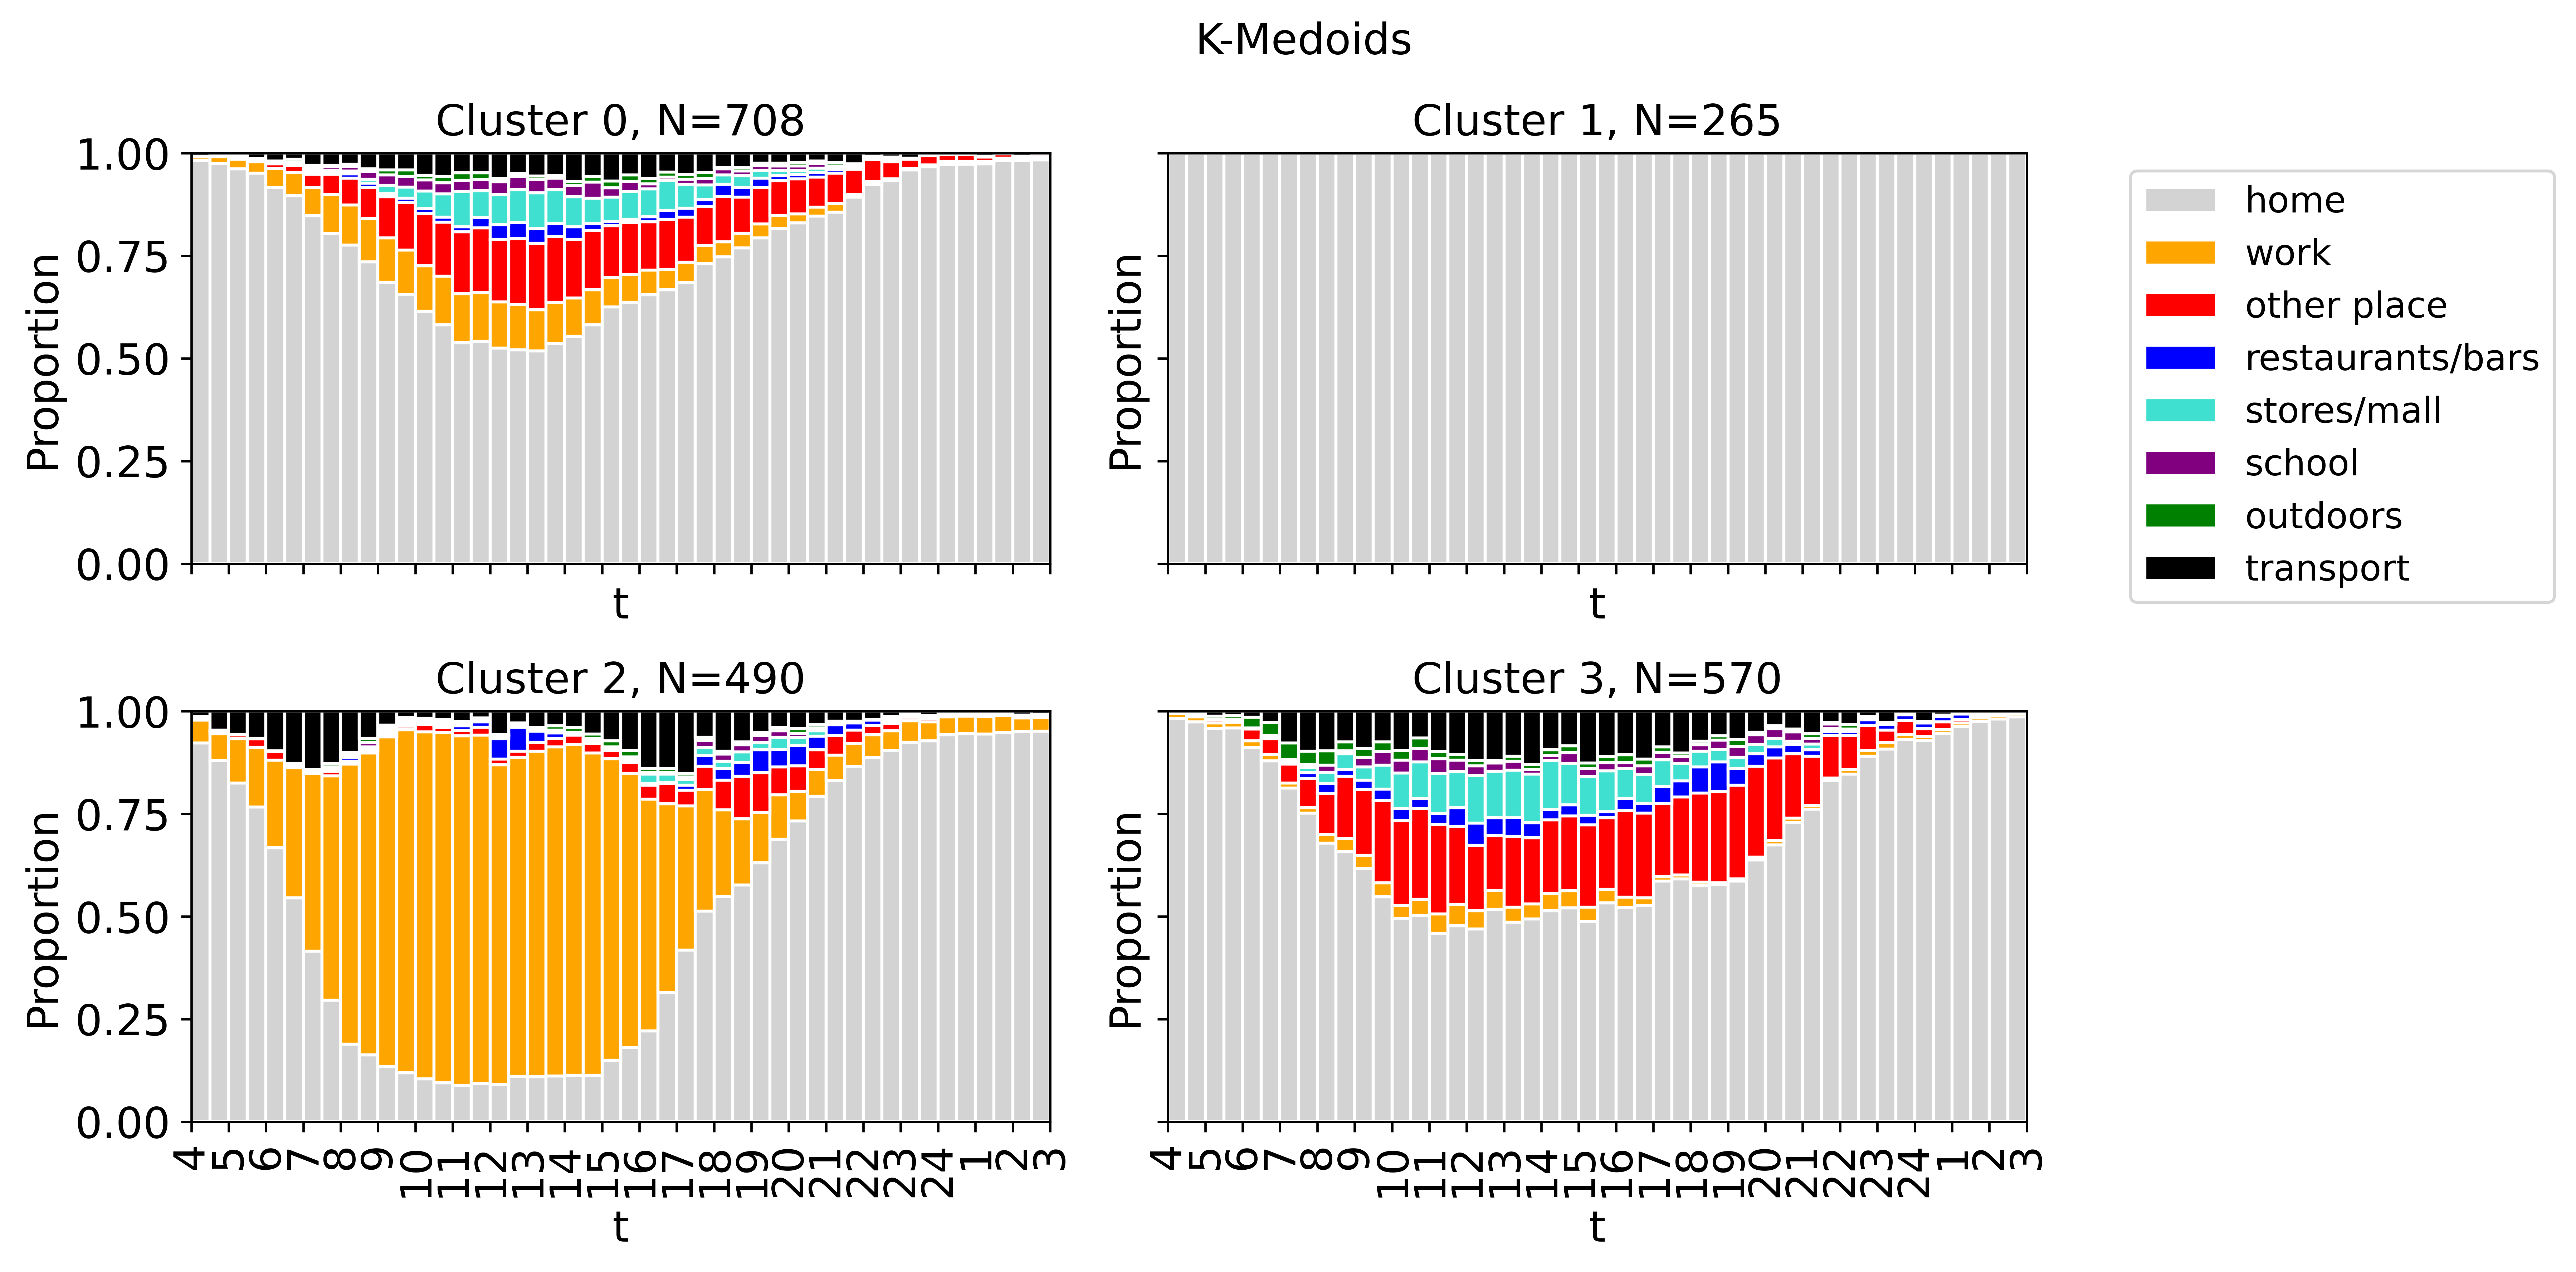

In [13]:
plot_tempogram(
    seq_data, 
    W, 
    cluster_results['labels'], 
    suptitle='K-Medoids', 
    legend_labels=TEWHERE_MAP_LABELS
)

In [14]:
atus_meta = atus.build_grouped_meta(
    df=resp,
    base_cols=["TUCASEID", "TUFINLWGT", "GTCBSA"],
    group_specs=STRATIFICATION_SPEC,
    cluster_labels=cluster_results['labels'],
    joint_vars=list(STRATIFICATION_SPEC.keys()),
)
atus_meta

,TUCASEID,TUFINLWGT,GTCBSA,income,income_cat,age,age_cat,joint,cluster_label
0,20040707040543,20255.140632,38060,2,75k-125k,2,45-66,10,2
1,20040707040558,8612.078956,38060,2,75k-125k,1,25-44,9,3
2,20040807040006,13895.869568,38060,1,35k-75k,2,45-66,6,0
3,20040807040542,39687.590746,38060,1,35k-75k,0,18-24,4,0
4,20040807040553,2537.938345,38060,0,<35k,2,45-66,2,3
...,...,...,...,...,...,...,...,...,...
2028,20191211192139,12177.142158,38060,0,<35k,1,25-44,1,3
2029,20191211192394,69774.777569,38060,1,35k-75k,0,18-24,4,2
2030,20191212190533,14709.465924,38060,1,35k-75k,3,67+,7,0
2031,20191212191319,28148.385455,38060,1,35k-75k,1,25-44,5,3


In [15]:
atus_meta.to_csv(OUT_PATH_META, index=False)
seq_data.to_csv(OUT_PATH_SEQ)

medoid_info = {
    "medoid_indices": {int(k): int(v) for k, v in cluster_results["medoids"].items()},
    "medoid_thresholds": {int(k): float(v) for k, v in medoid_thresholds.items()},
}

import json
with open(OUT_PATH_MEDOID_INFO, "w") as f:
    json.dump(medoid_info, f, indent=2)